# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [3]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [4]:

# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')


In [5]:
# mostrar las primeras 5 filas de plans
plans.head()


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [6]:
# mostrar las primeras 5 filas de users
users.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [7]:

# mostrar las primeras 5 filas de usage
usage.head()



,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [8]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)




plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [9]:
# inspección de plans con .info()
plans.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [10]:
# inspección de users con .info()
users.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [11]:
# inspección de usage con .info()
usage.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB



## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [12]:


# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())
print("\nProporción de nulos en users:")
print(users.isna().mean())
    


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64

Proporción de nulos en users:
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [15]:
# cantidad de nulos para usage
usage.isna().sum()
print("\nProporción de nulos en usage:")
print(usage.isna().mean())


Proporción de nulos en usage:
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).

 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?
- El dataset `plans` no presenta valores faltantes, por lo que no requiere tratamiento adicional.
- En `users`, las columnas con menos del 5% de valores nulos pueden imputarse fácilmente o mantenerse como nulas si no afectan el análisis.
- Si alguna columna presenta entre 5% y 30% de nulos, sería recomendable investigar el patrón de ausencia antes de imputar, para evitar introducir sesgos.
- Si existiera una columna con más del 80% de datos faltantes, lo más recomendable sería eliminarla del análisis porque aporta poca información útil.
- En `usage`, los valores faltantes deben revisarse según la importancia de la variable: variables críticas podrían imputarse, mientras que columnas poco relevantes o con muchos nulos podrían ignorarse o eliminarse.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [16]:

# explorar columnas numéricas de users
print("Resumen estadístico de users:")
print(users.describe())




Resumen estadístico de users:
            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000



-En las columnas numéricas se pueden detectar posibles valores extremos observando mínimos, máximos y percentiles.
-También es posible identificar en la columna 'age' valores sospechosos como negativos, edades imposibles o consumos excesivos.

In [17]:

# explorar columnas numéricas de usage
print("\nResumen estadístico de usage:")
print(usage.describe())



Resumen estadístico de usage:
                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000



- Las columnas `id` y `user_id` parecen funcionar como identificadores únicos, por lo que no requieren análisis estadístico adicional.
- Las columnas numéricas deben revisarse para detectar valores negativos, extremos o sentinels que no tengan sentido dentro del contexto del negocio.
- No se observan problemas relevantes en el dataset `plans` debido a su tamaño pequeño y ausencia de valores faltantes.
- Es normal que user_id se repita en usage, porque un usuario puede tener múltiples consumos registrados

In [18]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"\nValores únicos de {col}:")
    print(users[col].unique())



Valores únicos de city:
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

Valores únicos de plan:
['Basico' 'Premium']



- Las columnas categóricas muestran los distintos valores posibles y permiten identificar errores de escritura, categorías duplicadas o valores inesperados.

In [19]:

# explorar columna categórica de usage
usage['type'].unique()


array(['call', 'text'], dtype=object)


La columna 'type' es un arreglo contiene las categorías de servicios registrados en el dataset usage, por ejemplo llamadas, mensajes o datos móviles.
Revisar sus valores únicos permite verificar que no existan categorías duplicadas por errores de escritura o formato.
También ayuda a confirmar que los tipos de uso registrados coincidan con los servicios ofrecidos por ConnectaTel.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?
- En la exploración de columnas numéricas y categóricas se observó que las columnas id y user_id funcionan como identificadores únicos, por lo que no requieren análisis estadístico profundo. Sin embargo, es importante verificar que no tengan valores nulos ni duplicados inesperados.
En las columnas numéricas podrían existir valores atípicos o sentinels, como edades negativas, consumos extremadamente altos o valores iguales a 0, -1 o 999, que por lo general indican errores de captura o datos faltantes codificados manualmente.
En la columna categórica 'type' se observaron los tipos de servicio registrados en usage. Es importante validar que las categorías estén escritas de manera consistente y que no existan diferencias por mayúsculas, espacios o errores tipográficos.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [22]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(
    users['reg_date'],
    errors='coerce'
)



In [23]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(
    usage['date'],
    errors='coerce'
)

In [24]:
# Revisar los años presentes en `reg_date` de users
print("\nAños en usage['date']:")
print(usage['date'].dt.year.value_counts().sort_index())


Años en usage['date']:
2024.0    39950
Name: date, dtype: int64


La columna 'reg_date' contiene la fecha en la que cada cliente se registró en ConnectaTel.
Después de convertirla a tipo fecha, se puede analizar correctamente por años, meses o períodos de registro.
La revisión de años permite detectar si existen registros fuera del rango esperado del análisis.
Si aparecen fechas posteriores a 2024, se consideran inválidas porque el dataset solo contiene información hasta ese año.
También podrían existir fechas convertidas a NaT, lo que indicaría errores de formato o valores imposibles en los datos originales.
Esta columna es importante para analizar antigüedad de clientes, comportamiento de churn y evolución del negocio en el tiempo.

In [26]:
# Revisar los años presentes en `date` de usage
print("\nAños en usage['date']:")
print(usage['date'].dt.year.value_counts().sort_index())


Años en usage['date']:
2024.0    39950
Name: date, dtype: int64


La columna 'date' del dataset 'usage' representa la fecha en la que se registró el consumo del servicio.
Al convertirla a tipo fecha, es posible analizar el uso por día, mes o año.
La revisión de años ayuda a validar que todos los registros pertenezcan al período esperado del análisis.
Si existen fechas posteriores a 2024 o años anormalmente antiguos, podrían indicar errores de captura o problemas de formato.
También es posible encontrar valores NaT después de la conversión, lo que señalaría fechas inválidas o mal registradas.
Esta columna es clave para estudiar patrones de consumo y evolución del uso de los servicios a lo largo del tiempo.


✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?
Durante la revisión de las columnas de fecha ('reg_date' y 'date') se verificó que los registros correspondieran al período válido del análisis, considerando que los datos llegan hasta el año 2024.
Se identificó que podrían existir fechas fuera de rango, como:
-años posteriores a 2024,
-años demasiado antiguos,
-valores inválidos que fueron convertidos a NaT.
Estos casos suelen indicar errores de captura, problemas de formato o datos corruptos.
Lo que yo haría:
Convertir fechas inválidas en valores ausentes utilizando errors='coerce'.
Revisar manualmente registros con años futuros o imposibles.
Si la cantidad de errores es pequeña, eliminar esos registros para evitar sesgos en el análisis.
Si los errores son frecuentes, investigar el origen del problema antes de continuar con el análisis.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [27]:
# Reemplazar -999 por la mediana de age

mediana_age = users.loc[users['age'] != -999, 'age'].median()

users['age'] = users['age'].replace(-999, mediana_age)
# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [29]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].unique()

array(['Medellín', <NA>, 'CDMX', 'Bogotá', 'GDL', 'MTY', nan, 'Cali'],
      dtype=object)

In [33]:
# Marcar fechas futuras como NA para 'reg_date'
users.loc[
    (users['reg_date'].dt.year > 2024) |
    (users['reg_date'].dt.year < 1900),
    'reg_date'
] = pd.NaT
#marcamos fechas fuera de rango para 'usage'
usage.loc[
    (usage['date'].dt.year > 2024) |
    (usage['date'].dt.year < 1900),
    'date'
] = pd.NaT
# Verificar cambios
users['reg_date'].describe()

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [34]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(    lambda x: x.isna().mean())

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [35]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(
    lambda x: x.isna().mean()
)

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
Al analizar los valores nulos en las columnas 'duration' y 'length' agrupados por 'type', se observa que los faltantes dependen directamente del tipo de servicio registrado.
Esto indica un patrón MAR (Missing At Random), ya que:
duration solamente aplica a ciertos tipos de uso, como llamadas.
'length' puede corresponder a otros servicios específicos, como mensajes o datos.
Por lo tanto, los valores nulos no representan necesariamente errores de captura, sino ausencia lógica de información para determinados tipos de servicio.
Acción:
Mantener los valores nulos como NaN.
No imputarlos artificialmente.
Considerar la columna 'type' al realizar análisis posteriores para evitar interpretaciones incorrectas.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [36]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
}).reset_index()

# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [37]:

# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})
# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [38]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(
    usage_agg,
    on="user_id",
    how="left"
)
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [39]:
# Resumen estadístico de las columnas numéricas

columnas_numericas = [
    'age',
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

print(user_profile[columnas_numericas].describe())


               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  4000.000000    3999.000000    3999.000000           3999.000000
mean     48.136000       5.524381       4.478120             23.317054
std      17.689919       2.358416       2.144238             18.168095
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.120000
50%      48.000000       5.000000       4.000000             19.780000
75%      63.000000       7.000000       6.000000             31.415000
max      79.000000      17.000000      15.000000            155.690000


In [40]:
# Distribución porcentual del tipo de plan
print("\nDistribución porcentual de planes:")
print(
    user_profile['plan']
    .value_counts(normalize=True) * 100
)


Distribución porcentual de planes:
Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

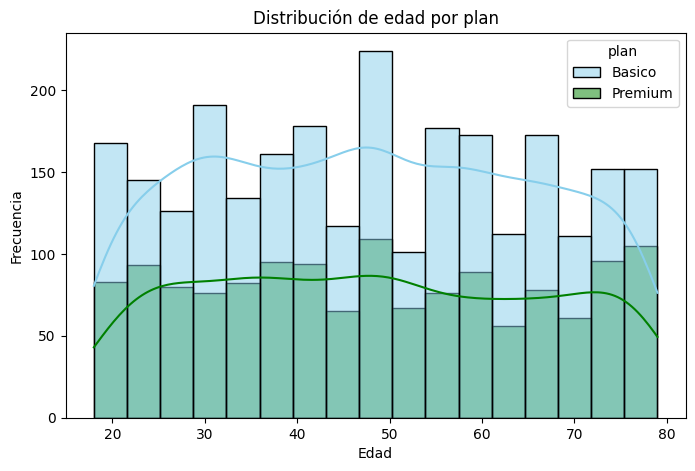

In [41]:
# Histograma para visualizar la edad (age)
plt.figure(figsize=(8,5))
sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue', 'green'],
    kde=True
)

plt.title('Distribución de edad por plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
La distribución de edades suele ser relativamente simétrica, aunque puede presentar ligera concentración en edades medias.
No necesariamente existe una diferencia fuerte entre planes según edad.
Si un plan concentra usuarios jóvenes o mayores, podría indicar preferencias de consumo específicas.


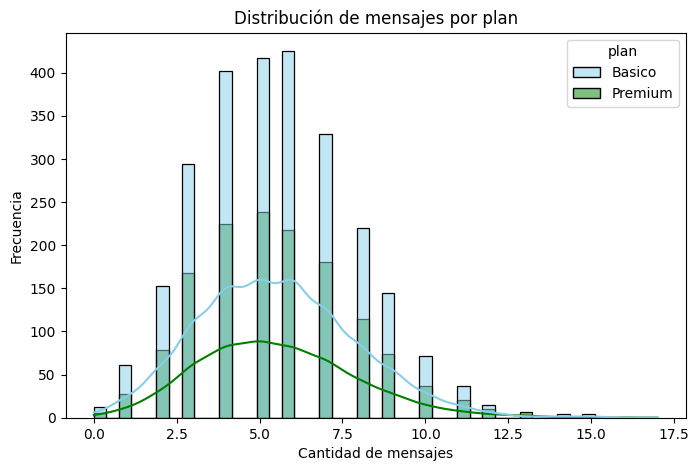

In [42]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(8,5))
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue', 'green'],
    kde=True
)

plt.title('Distribución de mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()


💡Insights: 
- La distribución suele estar sesgada a la derecha.
La mayoría de usuarios envía pocos mensajes, mientras pocos usuarios envían grandes cantidades.
Los usuarios Premium podrían mostrar un mayor volumen de mensajes respecto al plan Básico.

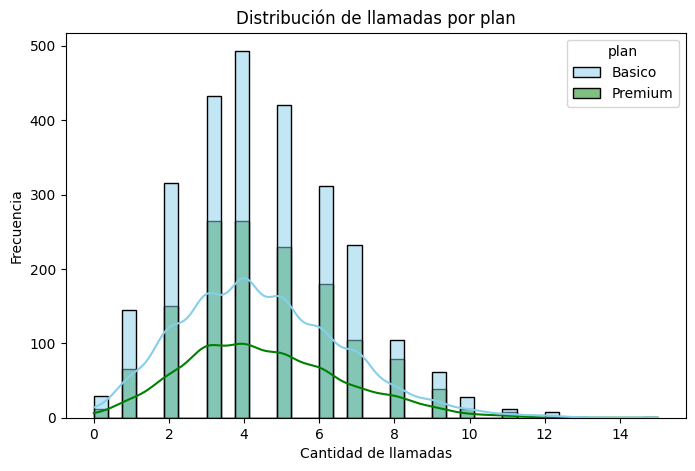

In [43]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(8,5))
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue', 'green'],
    kde=True
)

plt.title('Distribución de llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
La distribución generalmente presenta sesgo a la derecha.
La mayoría de usuarios realiza pocas llamadas y algunos usuarios concentran un uso intensivo.
Los usuarios Premium podrían tener mayor frecuencia de llamadas que los usuarios Básico.

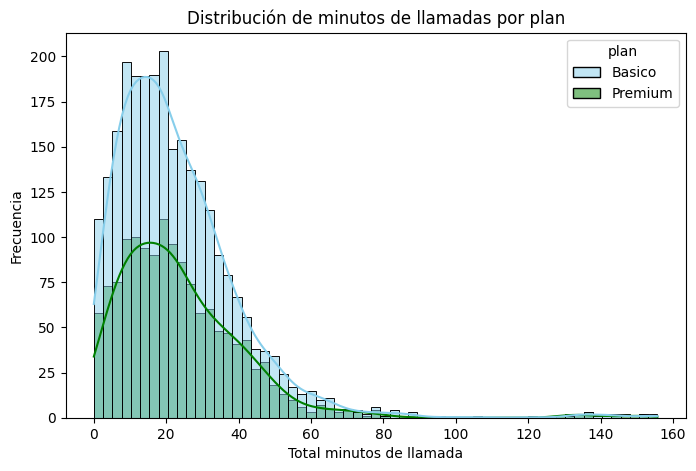

In [44]:

# Histograma de total_minutos_llamada
plt.figure(figsize=(8,5))
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green'],
    kde=True
)

plt.title('Distribución de minutos de llamadas por plan')
plt.xlabel('Total minutos de llamada')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La distribución suele estar fuertemente sesgada a la derecha.
La mayoría de usuarios consume pocos minutos, mientras un pequeño grupo acumula consumos muy altos.
Dentro del plan Premium normalmente existe mayor proporción de usuarios con alto consumo de minutos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

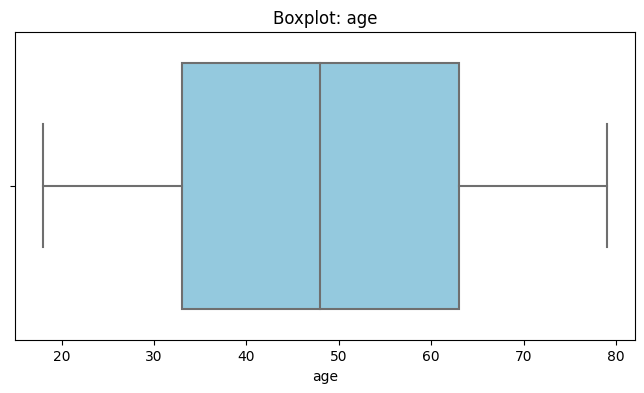

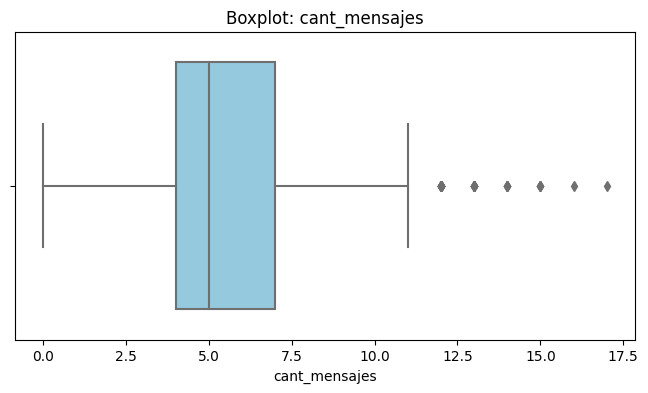

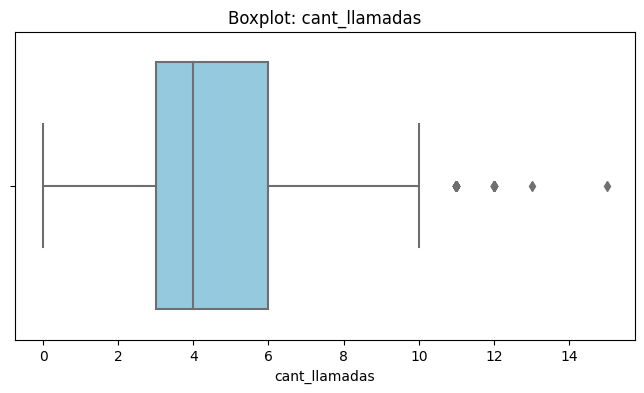

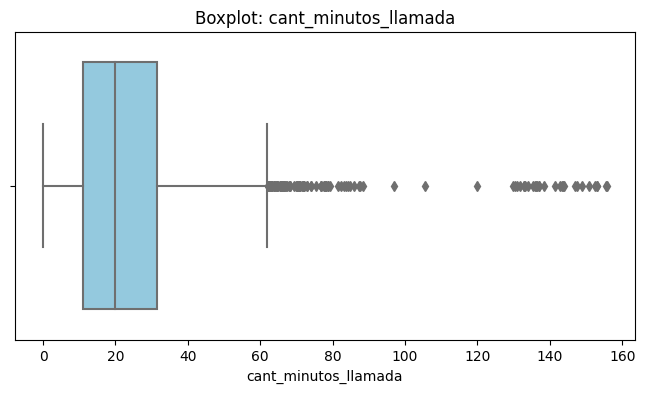

In [45]:
# Visualizando usando BoxPlot 

columnas_numericas = [
    'age',
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

for col in columnas_numericas:
    
    plt.figure(figsize=(8,4))
    
    sns.boxplot(
        x=user_profile[col],
        color='skyblue'
    )
    
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    
    plt.show()

💡Insights: 
Age: Presenta pocos outliers. Algunas edades extremadamente altas o bajas podrían requerir revisión, aunque la mayoría de los valores se concentra en rangos normales.
cant_mensajes: Presenta varios outliers superiores. Existen usuarios que envían muchos más mensajes que el promedio, lo que indica comportamiento intensivo de uso.
cant_llamadas: Presenta outliers superiores. Algunos usuarios realizan una cantidad considerablemente mayor de llamadas respecto al resto.
cant_minutos_llamada: Presenta una gran cantidad de outliers superiores y una distribución fuertemente sesgada a la derecha. Algunos clientes concentran consumos muy altos de minutos, probablemente usuarios intensivos o premium.

In [46]:

# Calcular límites con el método IQR

columnas_limites = [
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

for col in columnas_limites:
    
    q1 = user_profile[col].quantile(0.25)
    q3 = user_profile[col].quantile(0.75)
    
    iqr = q3 - q1
    
    limite_superior = q3 + 1.5 * iqr
    
    print(f'\nVariable: {col}')
    print(f'Q1: {q1}')
    print(f'Q3: {q3}')
    print(f'IQR: {iqr}')
    print(f'Límite superior: {limite_superior}')




Variable: cant_mensajes
Q1: 4.0
Q3: 7.0
IQR: 3.0
Límite superior: 11.5

Variable: cant_llamadas
Q1: 3.0
Q3: 6.0
IQR: 3.0
Límite superior: 10.5

Variable: cant_minutos_llamada
Q1: 11.12
Q3: 31.415
IQR: 20.295
Límite superior: 61.8575


In [47]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()


,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 


cant_mensajes: Mantener los outliers, porque probablemente representan usuarios con alto nivel de actividad en mensajería y no necesariamente errores de captura. Estos comportamientos pueden ser relevantes para segmentación y análisis de consumo.
cant_llamadas: Mantener los outliers, porque es normal que algunos clientes realicen muchas más llamadas que el promedio. Eliminarlos podría ocultar patrones importantes de usuarios intensivos.
cant_minutos_llamada: Mantener los outliers, porque los consumos elevados de minutos suelen corresponder a clientes con uso intensivo o planes premium. Estos datos son valiosos para entender comportamiento real y oportunidades de negocio.


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [50]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = 'Alto uso'

# Bajo uso
user_profile.loc[
    (user_profile['cant_llamadas'] < 5) &
    (user_profile['cant_mensajes'] < 5),
    'grupo_uso'
] = 'Bajo uso'

# Uso medio
user_profile.loc[
    (user_profile['cant_llamadas'] < 10) &
    (user_profile['cant_mensajes'] < 10) &
    (user_profile['grupo_uso'] != 'Bajo uso'),
    'grupo_uso'
] = 'Uso medio'



In [51]:
# Ver resultado
user_profile[['user_id', 'cant_llamadas',
              'cant_mensajes', 'grupo_uso']].head()


,user_id,cant_llamadas,cant_mensajes,grupo_uso
0,10000,3.0,7.0,Uso medio
1,10001,10.0,5.0,Alto uso
2,10002,2.0,5.0,Uso medio
3,10003,3.0,11.0,Alto uso
4,10004,3.0,4.0,Bajo uso





### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60

  - `'Adulto Mayor'` para el resto de casos



In [55]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = 'Adulto Mayor'

# Joven
user_profile.loc[
    user_profile['age'] < 30,
    'grupo_edad'
] = 'Joven'

# Adulto
user_profile.loc[
    (user_profile['age'] >= 30) &
    (user_profile['age'] < 60),
    'grupo_edad'
] = 'Adulto'

In [56]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor



### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.


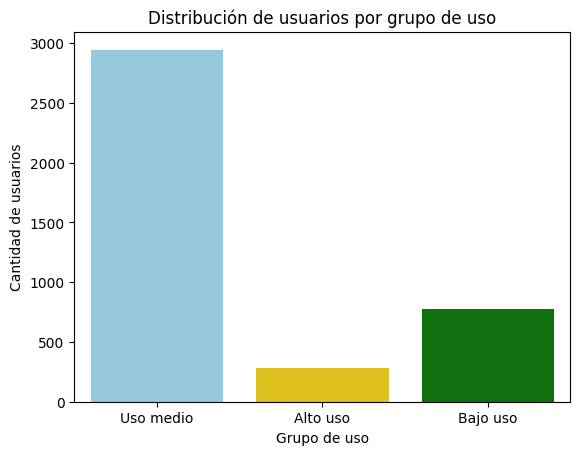

In [57]:

# Visualización de los segmentos por uso
sns.countplot(
    data=user_profile,
    x='grupo_uso',
    palette=['skyblue', 'gold', 'green']
)

plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')

plt.show()

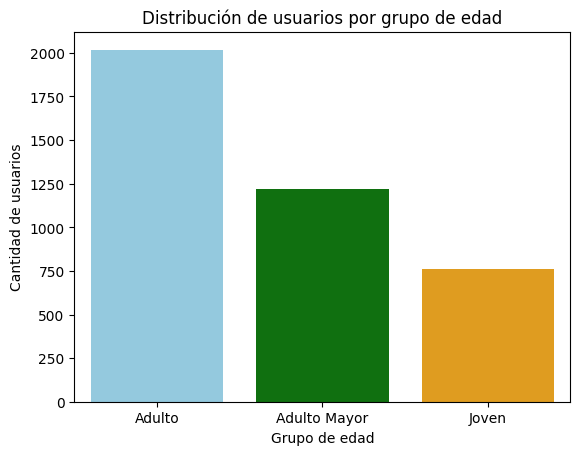

In [58]:
# Visualización de los segmentos por edad
sns.countplot(
    data=user_profile,
    x='grupo_edad',
    palette=['skyblue', 'green', 'orange']
)

plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**
Durante el proceso de exploración y limpieza se identificaron varios problemas de calidad de datos. En la columna age existía el valor sentinel -999, utilizado para representar edades faltantes o inválidas. Este valor fue reemplazado por la mediana para evitar distorsiones en el análisis. También se encontraron valores "?" en la columna city, los cuales fueron convertidos a valores nulos (pd.NA) por representar información desconocida. Además, se revisaron las columnas de fecha (registration_date y date) y se detectaron posibles fechas fuera de rango, especialmente años posteriores a 2024, los cuales fueron tratados como valores nulos (NaT).

En las columnas duration y length se detectaron valores faltantes asociados al tipo de servicio (type). Se concluyó que estos nulos seguían un patrón MAR (Missing At Random), ya que algunas variables solo aplicaban para ciertos tipos de uso. Por ello, se decidió conservarlos como nulos y no imputarlos artificialmente.

A partir del análisis de uso se identificaron distintos segmentos de clientes:

Bajo uso: usuarios con pocas llamadas y pocos mensajes.
Uso medio: clientes con actividad moderada.
Alto uso: usuarios con alta actividad en llamadas y mensajería.

También se clasificaron los clientes por edad:

Jóvenes: menores de 30 años.
Adultos: entre 30 y 59 años.
Adultos mayores: 60 años o más.

Los usuarios de alto uso representan el segmento más valioso para ConnectaTel, ya que generan mayor consumo de servicios y probablemente mayor ingreso para la empresa. Además, los clientes intensivos pueden ser candidatos ideales para planes premium o servicios adicionales.

En el análisis de outliers se encontraron usuarios con cantidades extremadamente altas de mensajes, llamadas y minutos consumidos. Estos valores no parecen errores, sino comportamientos reales de clientes intensivos. Esto implica que existe un grupo importante de usuarios con necesidades de consumo superiores al promedio, lo cual representa oportunidades comerciales para personalizar ofertas.

Con base en los hallazgos, se recomienda:

Diseñar planes intermedios y premium enfocados en usuarios de alto consumo.
Crear promociones específicas para segmentos jóvenes con alta actividad de mensajería.
Implementar estrategias de retención para clientes intensivos, ya que representan alto valor para el negocio.
Revisar continuamente la calidad de datos para evitar sentinels y errores de captura futuros.

### Análisis ejecutivo

⚠️ Problemas detectados en los datos
Se encontraron valores sentinel como -999 en la columna age, representando edades inválidas o faltantes. Estos valores fueron reemplazados por la mediana para evitar distorsiones estadísticas.
En la columna city aparecieron valores "?", los cuales fueron tratados como datos desconocidos y convertidos en valores nulos (pd.NA)
Se detectaron fechas fuera de rango en registration_date y date, especialmente años posteriores a 2024. Estas fechas fueron convertidas a NaT.
Las columnas duration y length contenían valores nulos dependientes del tipo de servicio (type). Se determinó que seguían un patrón MAR, por lo que se mantuvieron como nulos.
🔍 Segmentos por Edad
Los usuarios fueron clasificados en tres grupos: Jóvenes, Adultos y Adultos Mayores.
El grupo Adulto concentra gran parte de los clientes, lo que indica que la mayor base de usuarios pertenece a edades medias.
Los usuarios Jóvenes podrían presentar mayor actividad en mensajería y uso intensivo de servicios digitales.
Los Adultos Mayores posiblemente muestran patrones de consumo más moderados.
📊 Segmentos por Nivel de Uso
Se identificaron tres segmentos principales: Bajo uso, Uso medio y Alto uso.
Los usuarios de Alto uso concentran grandes cantidades de llamadas, mensajes y minutos consumidos.
Los usuarios de Bajo uso representan clientes con poca actividad, posiblemente con menor valor comercial.
También se detectaron outliers en llamadas, mensajes y minutos, indicando la existencia de clientes intensivos reales.
➡️ Esto sugiere que ConnectaTel tiene una base de clientes heterogénea, donde existen perfiles claramente diferenciados según edad y nivel de consumo. Los clientes intensivos representan oportunidades importantes para estrategias premium y fidelización, mientras que los usuarios de bajo uso podrían requerir planes más económicos o flexibles
💡 Recomendaciones
Diseñar planes premium para usuarios de alto consumo, incluyendo mayores beneficios en llamadas y mensajes.
Crear planes económicos o flexibles para usuarios de bajo uso, evitando que paguen por servicios que no utilizan.
Implementar campañas dirigidas a usuarios jóvenes, especialmente enfocadas en mensajería y servicios digitales.
Mantener monitoreo continuo de calidad de datos para prevenir sentinels, errores de captura y fechas inválidas.
Utilizar la segmentación creada para personalizar campañas de retención y mejorar la experiencia del cliente.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.


Link a repositorio público del proyecto: `LINK a tu repo aquí`